In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_org = pd.read_csv('athlete_events.csv')
athlete = df_org.copy()
region_org = pd.read_csv('noc_regions.csv')
region= region_org.copy()

In [3]:
region

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
...,...,...,...
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN


In [4]:
athlete.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
athlete = athlete.merge(region , how = 'left' , on ='NOC' )
athlete

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN


In [6]:
athlete.rename(columns={'region': 'Region' , 'notes':'Notes'}, inplace= True)

# observations for Data cleaning
- change sex dtype
- games column is a redundant colmn, drop it
- null balues are only present in age, height, weight and medal column
- 

In [7]:
athlete['ID'].is_unique
# we can nt make ID as index

False

In [8]:
athlete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
 15  Region  270746 non-null  object 
 16  Notes   5039 non-null    object 
dtypes: float64(3), int64(2), object(12)
memory usage: 35.2+ MB


In [9]:
athlete['Sex'] = athlete['Sex'].astype('category')

In [10]:
athlete[athlete['Season'] == athlete['Games'].str.split(' ').str[1]]
# this tells that all the values in season are correct

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Region,Notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN


In [11]:
athlete.drop(columns='Games', inplace=True)

In [12]:
athlete.shape

(271116, 16)

In [13]:
athlete[~(athlete['Team'] == athlete['Region'])]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Region,Notes
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
10,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10 kilometres,NaN,USA,NaN
11,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 50 kilometres,NaN,USA,NaN
12,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10/15 kilometres Pu...,NaN,USA,NaN
13,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,NaN,USA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271100,135561,Frantiek Zyka,M,26.0,NaN,NaN,Czechoslovakia,TCH,1928,Summer,Amsterdam,Athletics,Athletics Men's Marathon,NaN,Czech Republic,NaN
271101,135562,Milan Zyka,M,24.0,173.0,68.0,Czechoslovakia,TCH,1972,Summer,Munich,Cycling,"Cycling Men's Team Pursuit, 4,000 metres",NaN,Czech Republic,NaN
271104,135564,Yevgeny Aleksandrovich Zykov,M,22.0,172.0,65.0,Russia-1,RUS,2002,Winter,Salt Lake City,Luge,Luge Mixed (Men)'s Doubles,NaN,Russia,NaN
271107,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN


In [14]:
athlete[~((athlete['Team'] == athlete['Region']) |(athlete['NOC'] == athlete['Region']))]


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Region,Notes
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
117,42,Thomas Valentin Aas,M,25.0,NaN,NaN,Taifun,NOR,1912,Summer,Stockholm,Sailing,Sailing Mixed 8 metres,Gold,Norway,NaN
192,87,Rost'om Omeris dze Abashidze,M,29.0,188.0,97.0,Soviet Union,URS,1964,Summer,Tokyo,Wrestling,"Wrestling Men's Light-Heavyweight, Greco-Roman",NaN,Russia,NaN
193,88,Nunu Dzhansuhivna Abashydze (-Myslaieva),F,25.0,168.0,105.0,Soviet Union,URS,1980,Summer,Moskva,Athletics,Athletics Women's Shot Put,NaN,Russia,NaN
238,116,Hosni Mohamed Abbas,M,28.0,NaN,60.0,United Arab Republic,UAR,1960,Summer,Roma,Weightlifting,Weightlifting Men's Featherweight,NaN,Syria,United Arab Republic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271080,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN
271100,135561,Frantiek Zyka,M,26.0,NaN,NaN,Czechoslovakia,TCH,1928,Summer,Amsterdam,Athletics,Athletics Men's Marathon,NaN,Czech Republic,NaN
271101,135562,Milan Zyka,M,24.0,173.0,68.0,Czechoslovakia,TCH,1972,Summer,Munich,Cycling,"Cycling Men's Team Pursuit, 4,000 metres",NaN,Czech Republic,NaN
271104,135564,Yevgeny Aleksandrovich Zykov,M,22.0,172.0,65.0,Russia-1,RUS,2002,Winter,Salt Lake City,Luge,Luge Mixed (Men)'s Doubles,NaN,Russia,NaN


<Axes: xlabel='Name'>

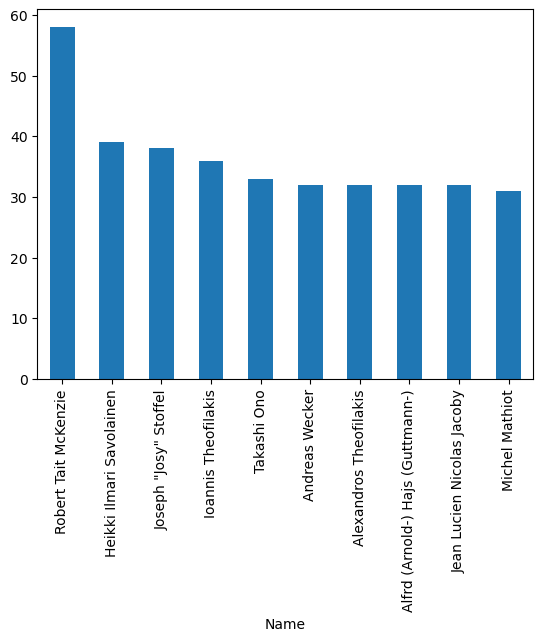

In [15]:
# athelete who participated the most
athlete['Name'].value_counts(ascending = False).head(10).plot(kind='bar')

Text(0.5, 1.0, 'Gender Distribution')

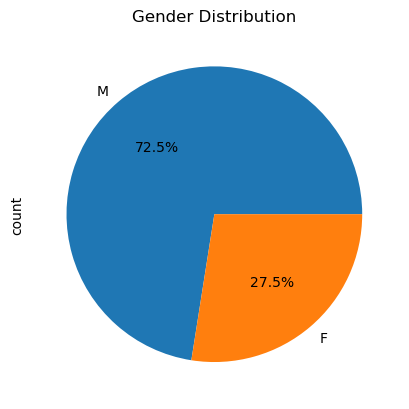

In [16]:
athlete['Sex'].value_counts().plot(kind='pie' ,autopct='%1.1f%%')
plt.title('Gender Distribution')

<Axes: xlabel='Sport'>

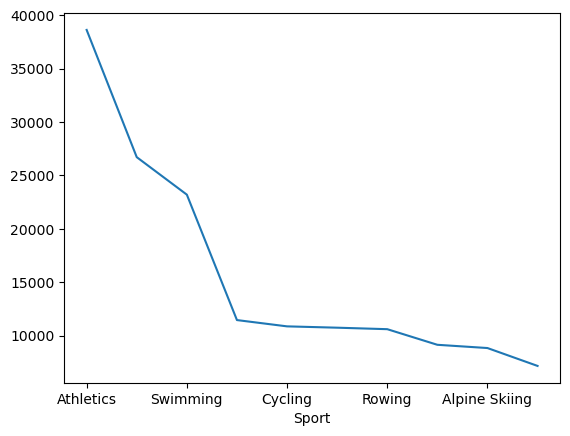

In [17]:
athlete['Sport'].value_counts(ascending = False).head(10).plot()

In [18]:
athlete[(athlete['Notes'].notnull()) & (athlete['Notes'] != athlete['Team'])].value_counts()
# this shows that almost every notes column is a redundant column and can be dropped

ID     Name                    Sex  Age   Height  Weight  Team                          NOC  Year  Season  City    Sport         Event                            Medal   Region              Notes         
49468  Peter William Holmberg  M    27.0  180.0   90.0    United States Virgin Islands  ISV  1988  Summer  Seoul   Sailing       Sailing Mixed One Person Dinghy  Silver  Virgin Islands, US  Virgin Islands    1
61639  Ko Lai Chak             M    28.0  165.0   61.0    Hong Kong-2                   HKG  2004  Summer  Athina  Table Tennis  Table Tennis Men's Doubles       Silver  China               Hong Kong         1
69319  Li Ching                M    29.0  166.0   55.0    Hong Kong-2                   HKG  2004  Summer  Athina  Table Tennis  Table Tennis Men's Doubles       Silver  China               Hong Kong         1
Name: count, dtype: int64

In [19]:
athlete.drop(columns='Notes' , inplace=True)

<Axes: title={'center': 'Top countries participation'}, xlabel='Team'>

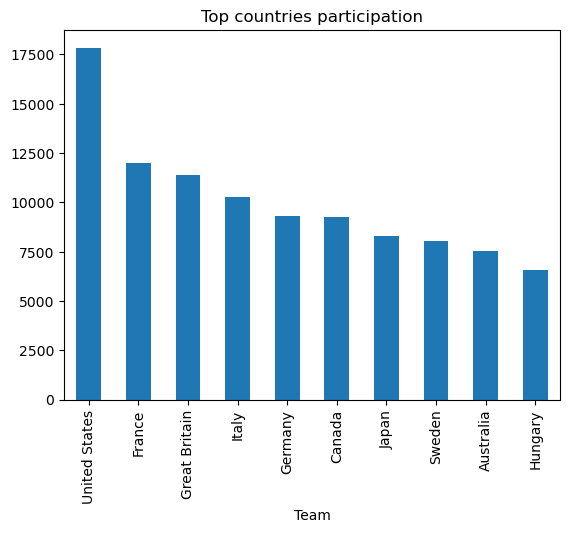

In [20]:
# countries who participated the most
top_countries = athlete['Team'].value_counts(ascending = False).head(10).plot(kind='bar')
plt.title('Top countries participation')
top_countries

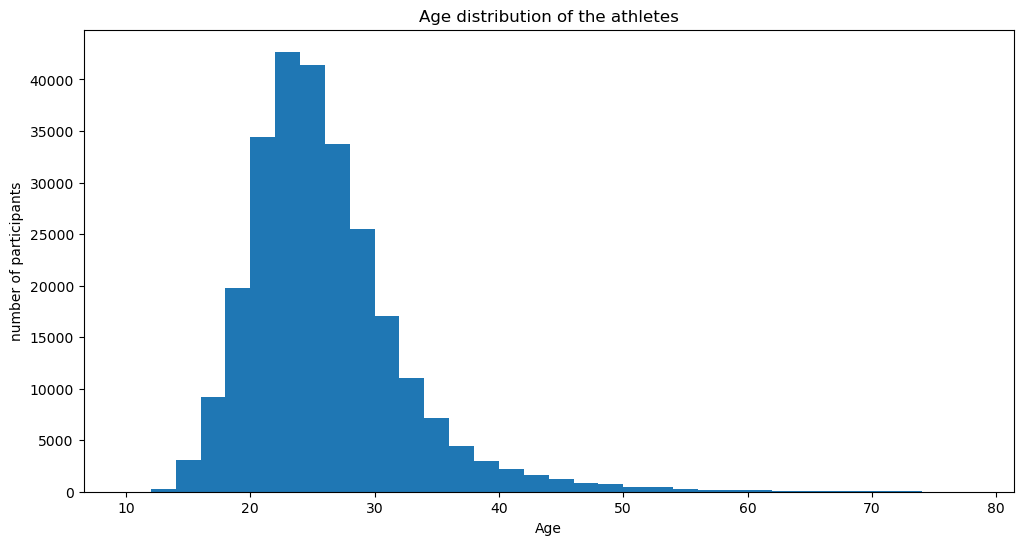

In [21]:
# age distribution of the participants
plt.figure(figsize=(12,6))
plt.title('Age distribution of the athletes')
plt.xlabel('Age')
plt.ylabel('number of participants')
plt.hist(athlete['Age'], bins=np.arange(10,80,2))
plt.show()

In [22]:
# what aer the winter sports
winter_sports = athlete[athlete['Season'] =='Winter']['Sport'].unique()
winter_sports

array(['Speed Skating', 'Cross Country Skiing', 'Ice Hockey', 'Biathlon',
       'Alpine Skiing', 'Luge', 'Bobsleigh', 'Figure Skating',
       'Nordic Combined', 'Freestyle Skiing', 'Ski Jumping', 'Curling',
       'Snowboarding', 'Short Track Speed Skating', 'Skeleton',
       'Military Ski Patrol', 'Alpinism'], dtype=object)

In [23]:
# what aer the summer sports
winter_sports = athlete[athlete['Season'] =='Summer']['Sport'].unique()
winter_sports

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [24]:
# total medal
athlete['Medal'].value_counts()

Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64

In [25]:
# total no of female athlete in each olympics
female_participants_summer = athlete[(athlete['Sex'] == 'F') & (athlete['Season'] == 'Summer')]                     

C:\Users\23shr\AppData\Local\Temp\ipykernel_19660\4034845282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=female_participants_summer , palette='Spectral')


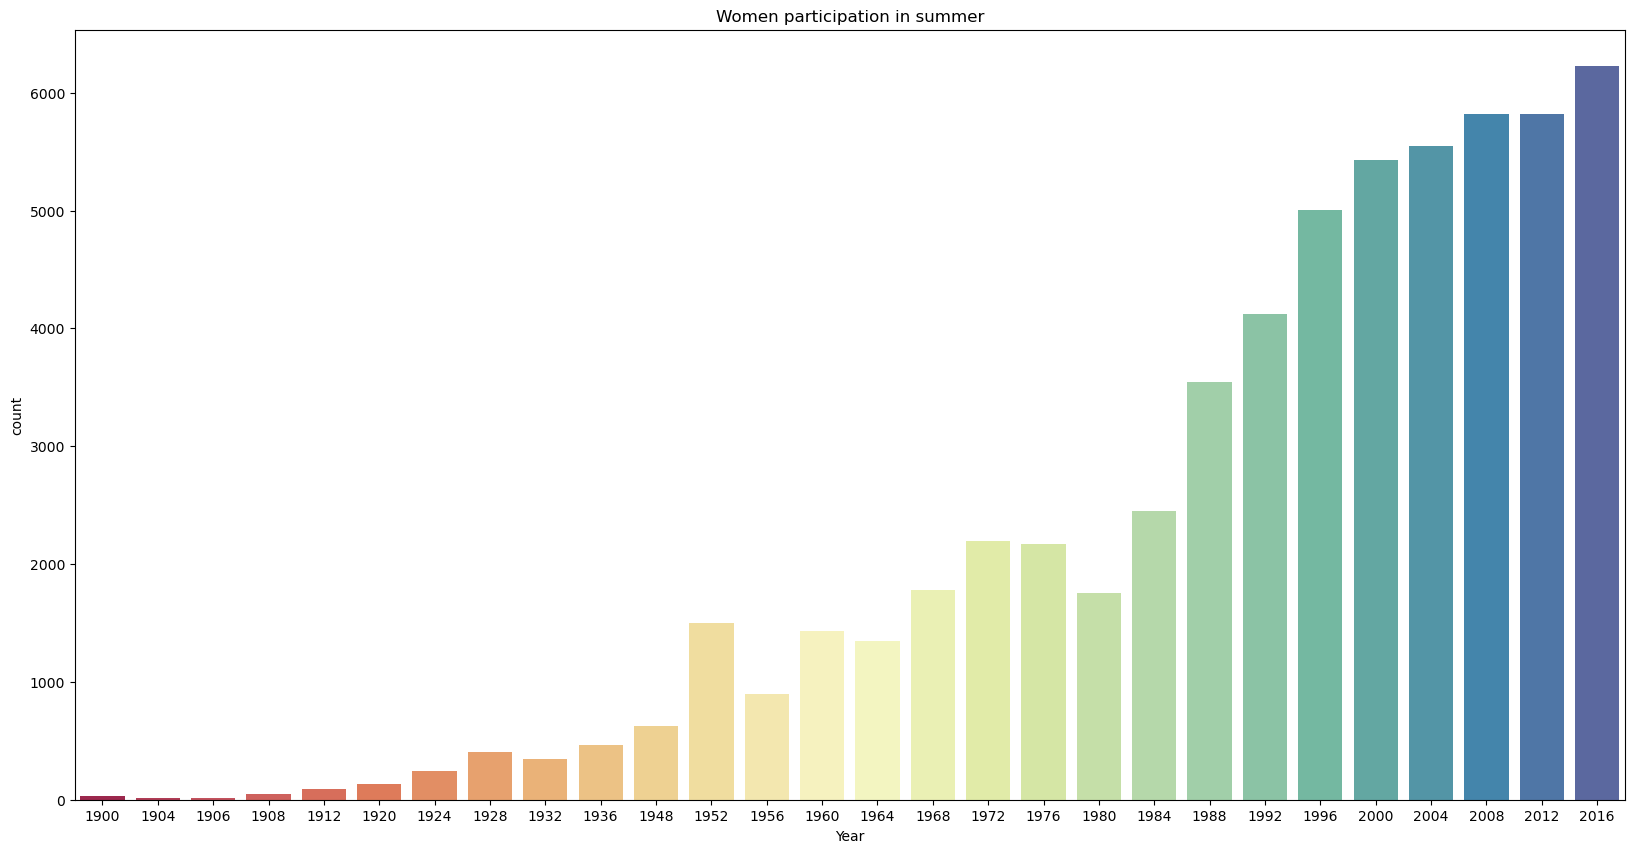

In [26]:
plt.figure(figsize=(20,10))
sns.countplot(x='Year', data=female_participants_summer , palette='Spectral')
plt.title('Women participation in summer')
plt.show()

In [27]:
female_participants_winter = athlete[(athlete['Sex'] == 'F') & (athlete['Season'] == 'Winter')]                     

C:\Users\23shr\AppData\Local\Temp\ipykernel_19660\1972605724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=female_participants_winter , palette='Spectral')


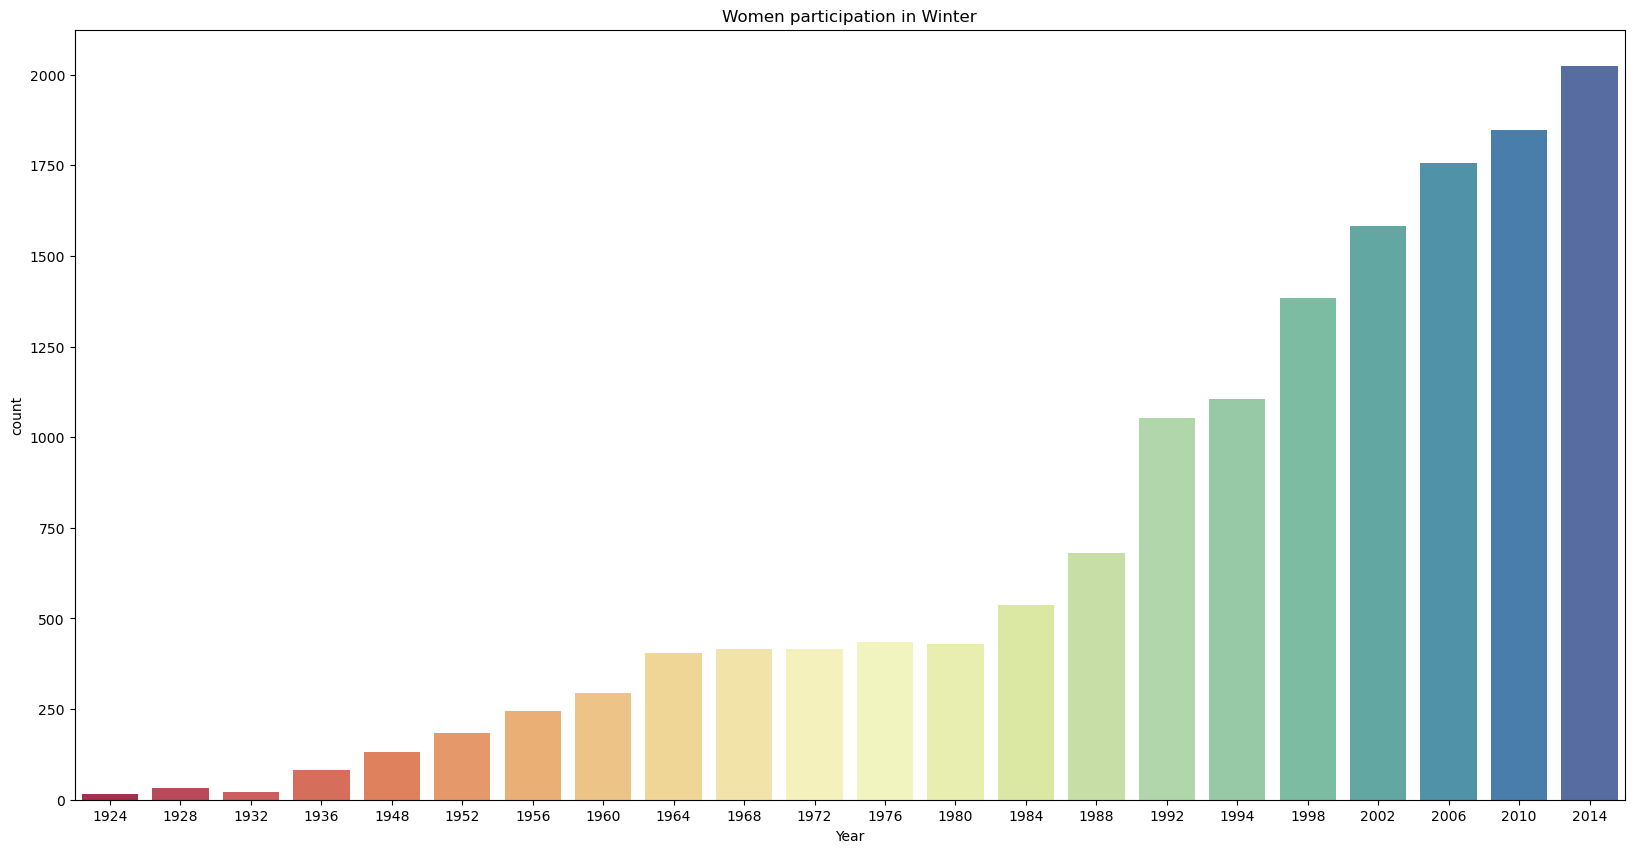

In [28]:
plt.figure(figsize=(20,10))
sns.countplot(x='Year', data=female_participants_winter , palette='Spectral')
plt.title('Women participation in Winter')
plt.show()

In [29]:
# Gold medal athletes
gold_medals = athlete[(athlete['Medal']=='Gold')]

In [30]:
gold_medals = gold_medals[gold_medals['Age'].notnull()]
gold_medals

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Region
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold,Finland
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold,Finland
60,20,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,1992,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Super G,Gold,Norway
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270981,135503,Zurab Zviadauri,M,23.0,182.0,90.0,Georgia,GEO,2004,Summer,Athina,Judo,Judo Men's Middleweight,Gold,Georgia
271009,135520,Julia Zwehl,F,28.0,167.0,60.0,Germany,GER,2004,Summer,Athina,Hockey,Hockey Women's Hockey,Gold,Germany
271016,135523,"Ronald Ferdinand ""Ron"" Zwerver",M,29.0,200.0,93.0,Netherlands,NED,1996,Summer,Atlanta,Volleyball,Volleyball Men's Volleyball,Gold,Netherlands
271049,135545,Henk Jan Zwolle,M,31.0,197.0,93.0,Netherlands,NED,1996,Summer,Atlanta,Rowing,Rowing Men's Coxed Eights,Gold,Netherlands


In [31]:
# gold beyond 60
gold_medals['ID'][gold_medals['Age']> 60].count()

np.int64(6)

In [32]:
sporting_event = gold_medals['Sport'][gold_medals['Age']>60]
sporting_event

104003    Art Competitions
105199               Roque
190952             Archery
226374             Archery
233390            Shooting
261102             Archery
Name: Sport, dtype: object

Text(0.5, 1.0, 'Gold Medlas for Athletes over 60 years')

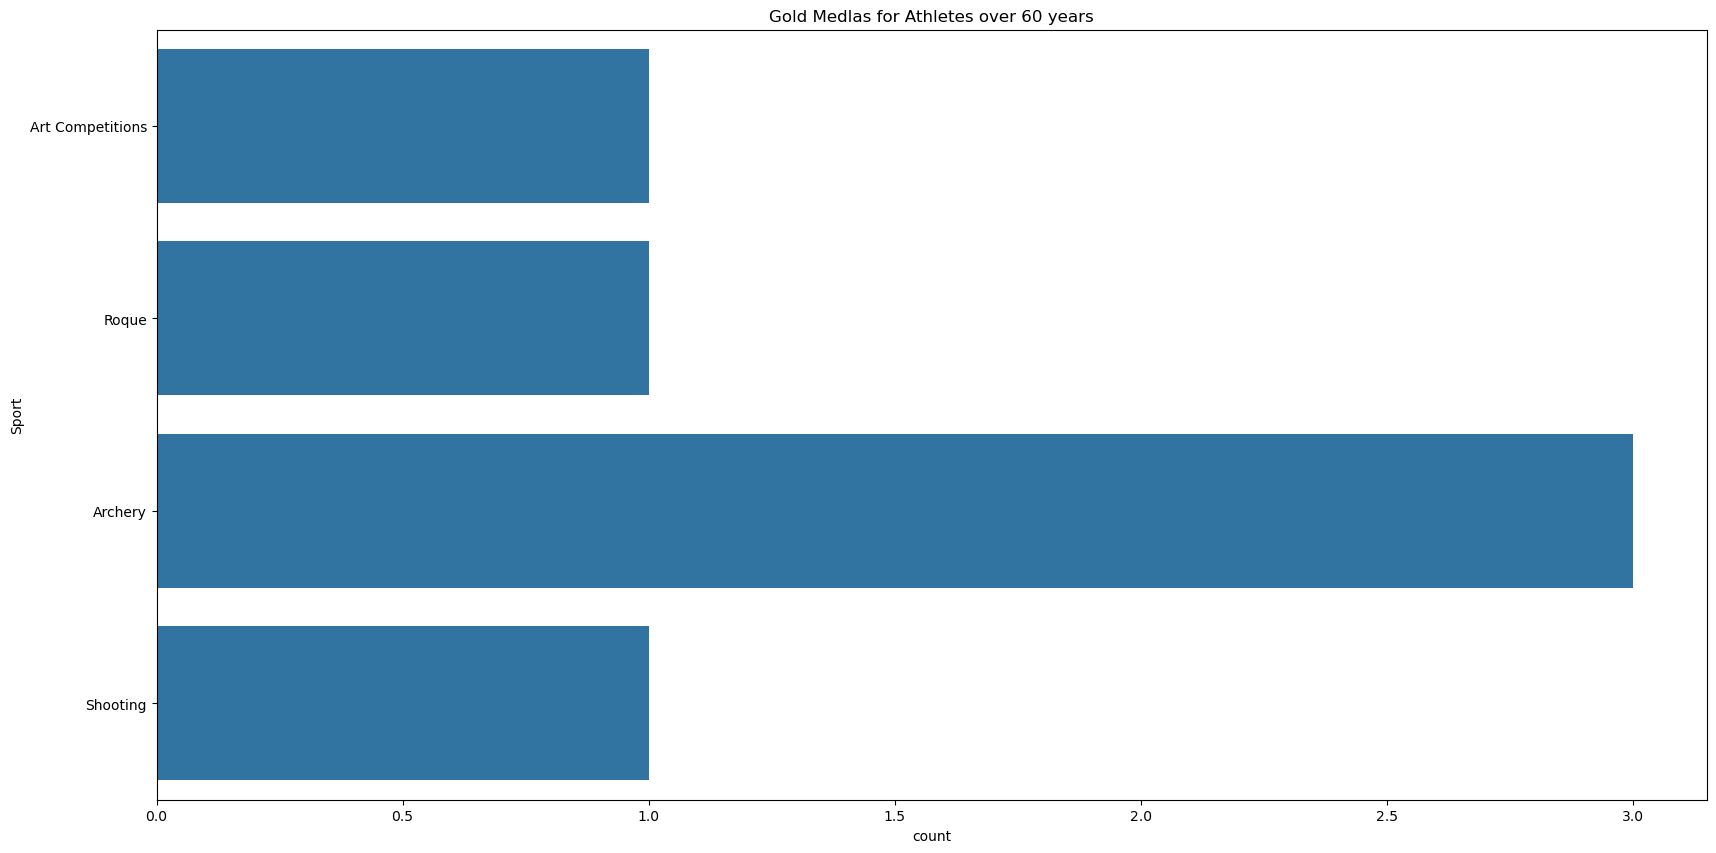

In [33]:
# plot for sporting_event
plt.figure(figsize=(20,10))
sns.countplot(sporting_event)
plt.title('Gold Medlas for Athletes over 60 years')

In [34]:
# gold medals from each country
totalGoldMedals=gold_medals['Region'].value_counts().reset_index(name = 'Medal').head()
totalGoldMedals

,Region,Medal
0,USA,2627
1,Russia,1599
2,Germany,1293
3,UK,657
4,Italy,567


C:\Users\23shr\AppData\Local\Temp\ipykernel_19660\3373185406.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='Region',y = 'Medal', data = totalGoldMedals, height = 5, kind = 'bar', palette='rocket')


Text(0.5, 1.0, 'Gold Medals per Country')

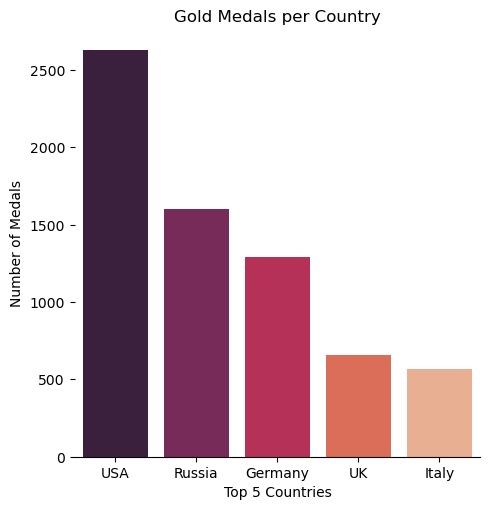

In [35]:
g = sns.catplot(x='Region',y = 'Medal', data = totalGoldMedals, height = 5, kind = 'bar', palette='rocket')
g.set_xlabels('Top 5 Countries')
g.despine(left = True)
g.set_ylabels('Number of Medals')
plt.title('Gold Medals per Country')

In [36]:
# rio olympics

max_year = athlete['Year'].max()
print(max_year)
team_names = athlete[(athlete['Year']== max_year) & (athlete['Medal'] == 'Gold')]['Team']
team_names.value_counts().head()

2016


Team
United States    137
Great Britain     64
Russia            50
Germany           47
China             44
Name: count, dtype: int64

Text(0.5, 0, 'Countrywise Medals for the year 2016')

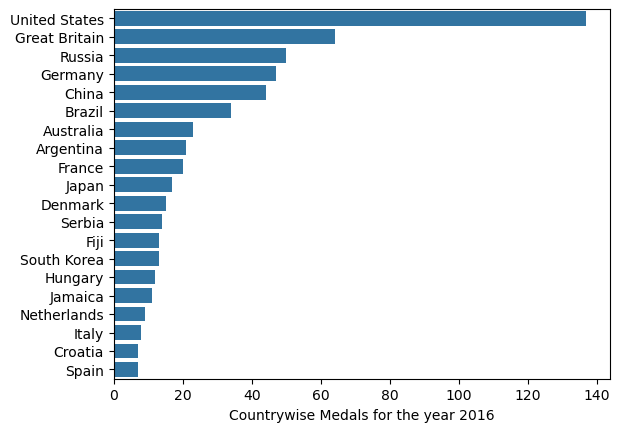

In [38]:
sns.barplot(x=team_names.value_counts().head(20), y = team_names.value_counts().head(20).index)
plt.ylabel(None)
plt.xlabel('Countrywise Medals for the year 2016')

In [39]:
not_null_medals = athlete[(athlete['Height'].notnull()) & athlete['Weight'].notnull()]

Text(0.5, 1.0, 'Height vs Weight of Olympics Medalists')

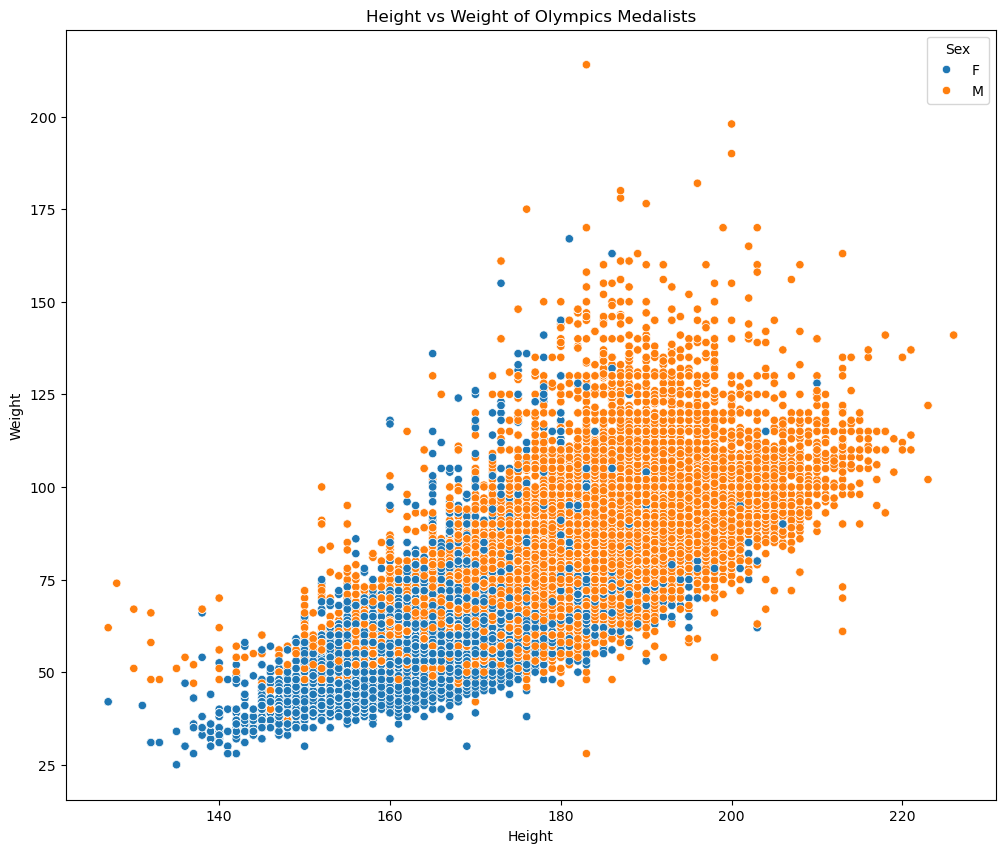

In [40]:
plt.figure(figsize=(12,10))
axis = sns.scatterplot(x = 'Height', y = 'Weight', data = not_null_medals, hue = 'Sex')
plt.title('Height vs Weight of Olympics Medalists')